# Big Compute Homework 2


## Install Pyspark


In [1]:
# Colab already has Java installed, so Spark can be installed easily with pip.
!pip install pyspark

In [2]:
import pyspark
print(pyspark.__file__)

/usr/local/lib/python3.12/dist-packages/pyspark/__init__.py


## Start a SparkSession
This will start a local Spark session.

In [3]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("Homewor2").getOrCreate()
sc = spark.sparkContext

In [15]:
# import dependencies
import pyspark.sql.types as T
import pyspark.sql.functions as F
from pyspark.sql import SparkSession
from pyspark.ml.feature import Binarizer, Bucketizer, OneHotEncoder, VectorAssembler, StringIndexer, MinMaxScalerModel, \
StandardScaler, Imputer, Tokenizer,StopWordsRemover, MinMaxScaler, PolynomialExpansion
from pyspark.ml.classification import GBTClassifier
from pyspark.ml import Pipeline
from pyspark.ml.clustering import KMeans, KMeansModel
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator, TrainValidationSplit
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator, ClusteringEvaluator, RegressionEvaluator
from pyspark.ml.recommendation import ALS
from pyspark.mllib.evaluation import RankingMetrics
from random import randint
from pprint import pprint
import matplotlib.pyplot as plt
import numpy as np; import pandas as pd

## Gradient Boosting

### Data Collection

In [6]:
df = spark.read.csv(
    "affairs.csv",
    inferSchema=True,
    header=True
)

df.printSchema()
df.describe().show()
print(df.count(), len(df.columns))
df.show(3)

root
 |-- rate_marriage: integer (nullable = true)
 |-- age: double (nullable = true)
 |-- yrs_married: double (nullable = true)
 |-- children: double (nullable = true)
 |-- religious: integer (nullable = true)
 |-- affairs: integer (nullable = true)

+-------+------------------+------------------+-----------------+------------------+------------------+------------------+
|summary|     rate_marriage|               age|      yrs_married|          children|         religious|           affairs|
+-------+------------------+------------------+-----------------+------------------+------------------+------------------+
|  count|              6366|              6366|             6366|              6366|              6366|              6366|
|   mean| 4.109644989004084|29.082862079798932| 9.00942507068803|1.3968740182218033|2.4261702796104303|0.3224945020420987|
| stddev|0.9614295945655025| 6.847881883668817|7.280119972766412| 1.433470828560344|0.8783688402641785| 0.467467779921086|
|    min| 

In [7]:
# number of rows, number of columns
df.count(), len(df.columns)

(6366, 6)

### Data Exploration and Preparation

In [8]:
# explore numerical data
df.describe('age').show()

+-------+------------------+
|summary|               age|
+-------+------------------+
|  count|              6366|
|   mean|29.082862079798932|
| stddev| 6.847881883668817|
|    min|              17.5|
|    max|              42.0|
+-------+------------------+



In [10]:
# explore categorical data
df.groupBy('rate_marriage').count().show()
df.groupBy('children').count().show()
df.groupBy('religious').count().show()

+-------------+-----+
|rate_marriage|count|
+-------------+-----+
|            1|   99|
|            3|  993|
|            5| 2684|
|            4| 2242|
|            2|  348|
+-------------+-----+

+--------+-----+
|children|count|
+--------+-----+
|     0.0| 2414|
|     1.0| 1159|
|     4.0|  328|
|     3.0|  781|
|     2.0| 1481|
|     5.5|  203|
+--------+-----+

+---------+-----+
|religious|count|
+---------+-----+
|        1| 1021|
|        3| 2422|
|        4|  656|
|        2| 2267|
+---------+-----+



In [9]:
# explore target
df.groupBy('affairs').count().show()

+-------+-----+
|affairs|count|
+-------+-----+
|      1| 2053|
|      0| 4313|
+-------+-----+



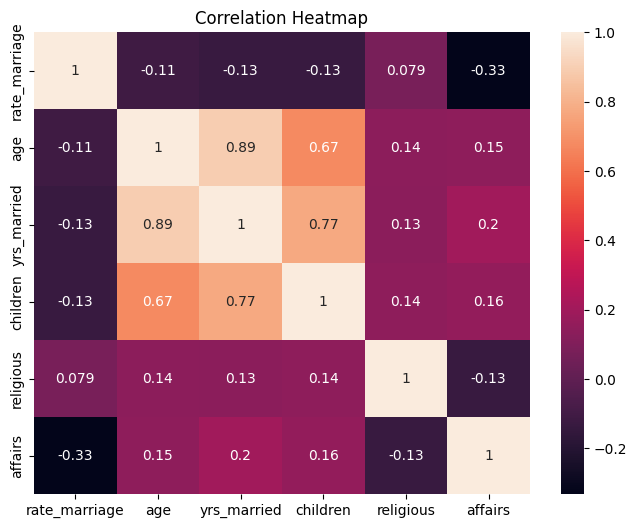

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ["rate_marriage", "age", "yrs_married", "children", "religious", "affairs"]
df_numeric = df.select(numeric_cols)
pdf = df_numeric.toPandas()

corr_matrix = pdf.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [27]:
# Split the dataset into training (75%) and testing (25%)
# randomSplit randomly divides the DataFrame based on the given proportions
train, test = df.randomSplit([0.75, 0.25])

# Create the validation set so that in this example we might use to debug the model when do manual tuning
train_inner, valid = train.randomSplit([0.8, 0.2], seed=42)

# Count the number of records in each split
# This helps verify the split ratio is approximately correct
print(train.count(), test.count())

# Check class distribution in the training set
# groupBy + count shows how many samples belong to each class (affairs = target variable)
train.groupBy('affairs').count().show()

# Check class distribution in the test set
# Important to ensure both sets have similar class balance (avoid bias)
test.groupBy('affairs').count().show()

4792 1574
+-------+-----+
|affairs|count|
+-------+-----+
|      1| 1562|
|      0| 3230|
+-------+-----+

+-------+-----+
|affairs|count|
+-------+-----+
|      1|  491|
|      0| 1083|
+-------+-----+



### Modelling

In [16]:
# Create a VectorAssembler to combine multiple feature columns into a single vector column
# Spark ML models expect input features in a single vector format (not separate columns)

vector_assembler = VectorAssembler(
    inputCols=['rate_marriage', 'age', 'yrs_married', 'children', 'religious'],  # selected independent variables
    outputCol="featureVector"  # new column that will store all features as a vector
)

# After transformation, each row will have:
# featureVector = [rate_marriage, age, yrs_married, children, religious]

In [17]:
# Initialize a Gradient Boosted Trees (GBT) classifier
# GBT is an ensemble method that builds trees sequentially,
# where each new tree tries to correct errors from previous ones (boosting concept)

gbt_classifier = GBTClassifier(
    labelCol="affairs",          # target variable (what we want to predict)
    featuresCol="featureVector", # input features (must be a vector column from VectorAssembler)
    predictionCol="prediction",  # output column storing predicted class (0 or 1)
)

# After training:
# model = gbt_classifier.fit(train)

# After prediction:
# result = model.transform(test)

# The result DataFrame will contain:
# - prediction → final predicted class
# - probability → probability of each class
# - rawPrediction → internal score before probability conversion

In [20]:
# Pipeline chains multiple stages into one workflow:
# Step 1: Convert columns → feature vector
# Step 2: Train GBT model

df_pipeline = Pipeline(stages=[vector_assembler, gbt_classifier])

# ParamGridBuilder defines combinations of parameters to try
# This is used for model tuning (Grid Search)

# trick - When you use ( ) parentheses, Python automatically allows multi-line expressions without using '\'.
paramGrid = (
    ParamGridBuilder()
    .addGrid(gbt_classifier.maxIter, [10, 20, 30]) # number of boosting iterations (trees)
    .addGrid(gbt_classifier.maxDepth, [2,3,5,6,8,9,10]) # tree depth (model complexity)
    .build()
)

# BinaryClassificationEvaluator evaluates model performance
# rawPrediction is used internally (before probability conversion)
# Default metric = areaUnderROC (AUC)

evaluator = BinaryClassificationEvaluator(
    rawPredictionCol='rawPrediction',
    labelCol='affairs'
)

# TrainValidationSplit:
# - Splits training data into train + validation (e.g., 80/20)
# - Trains models on train set
# - Evaluates on validation set
# - Selects best model

validator = TrainValidationSplit(
    estimator=df_pipeline,          # pipeline to train
    estimatorParamMaps=paramGrid,   # parameter combinations
    evaluator=evaluator,            # evaluation metric
    trainRatio=0.8                  # 80% train, 20% validation
)

# Train Model (Hyperparameter Tuning)
# This step:
# - tries all parameter combinations
# - performs cross-validation
# - selects the best model

validator_model = validator.fit(train)

# Make Predictions on Test Set
result = validator_model.transform(test)

# Inspect Results
# probability → probability of each class [P(0), P(1)]
# prediction → final predicted class (0 or 1)

result.select("affairs", "probability", "prediction").show(3, False)

+-------+----------------------------------------+----------+
|affairs|probability                             |prediction|
+-------+----------------------------------------+----------+
|1      |[0.4500062586481433,0.5499937413518567] |1.0       |
|1      |[0.48145906320193854,0.5185409367980615]|1.0       |
|1      |[0.3296672434842729,0.6703327565157271] |1.0       |
+-------+----------------------------------------+----------+
only showing top 3 rows


### Evaluation

In [25]:
# Compute AUC (Area Under ROC Curve)
# This measures how well the model separates the two classes
# Higher AUC means better ranking performance
rf_auc = BinaryClassificationEvaluator(labelCol='affairs').evaluate(result)
print(rf_auc)

# Compute F1-score
# F1 combines precision and recall into one metric
# Useful when the classes are imbalanced
rf_f1 = MulticlassClassificationEvaluator(
    labelCol='affairs',
    metricName='f1'
).evaluate(result)
print(rf_f1)

0.7571257467293853
0.7165534058792906


In [22]:
# Retrieve the best model selected by CrossValidator

# bestModel stores the pipeline with the best hyperparameter combination
best_model = validator_model.bestModel


# Print the parameters of the trained GBT model
# best_model.stages[1] refers to the second stage in the pipeline
# stage 0 = VectorAssembler
# stage 1 = GBTClassifier model
# extractParamMap() shows the final parameter settings of the best model
pprint(best_model.stages[1].extractParamMap())


# Extract feature importances from the trained GBT model
# Get the trained GBT model from the pipeline
gbt_model = best_model.stages[1]

# Pair each feature name with its importance score
# gbt_model.featureImportances returns the contribution of each feature
feature_importance_list = list(
    zip(df.columns[:-1], gbt_model.featureImportances.toArray())
)

# Sort features from most important to least important
feature_importance_list.sort(key=lambda x: x[1], reverse=True)

# Print the ranked feature importance list
pprint(feature_importance_list)

{Param(parent='GBTClassifier_274b7f58c37c', name='lossType', doc='Loss function which GBT tries to minimize (case-insensitive). Supported options: logistic'): 'logistic',
 Param(parent='GBTClassifier_274b7f58c37c', name='maxMemoryInMB', doc='Maximum memory in MB allocated to histogram aggregation. If too small, then 1 node will be split per iteration, and its aggregates may exceed this size.'): 256,
 Param(parent='GBTClassifier_274b7f58c37c', name='minInfoGain', doc='Minimum information gain for a split to be considered at a tree node.'): 0.0,
 Param(parent='GBTClassifier_274b7f58c37c', name='minInstancesPerNode', doc='Minimum number of instances each child must have after split. If a split causes the left or right child to have fewer than minInstancesPerNode, the split will be discarded as invalid. Should be >= 1.'): 1,
 Param(parent='GBTClassifier_274b7f58c37c', name='probabilityCol', doc='Column name for predicted class conditional probabilities. Note: Not all models output well-cal

### Improvement


In [34]:
# manual tuning (expected F1 > 0.70 on test set or validation set if you cannot make it at test set)
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# =========================================
# 1. Make predictions on train and validation
# =========================================
train_result = ### FIll your code ###
valid_result = ### FIll your code ###

# =========================================
# 2. Define evaluator (F1)
# =========================================
f1_evaluator = ### FIll your code ###

# =========================================
# 3. Compute F1 scores on train and validation
# =========================================
train_f1 = f1_evaluator.### FIll your code ###(train_result)
valid_f1 = f1_evaluator.### FIll your code ###(valid_result)

print(f"Train F1: {train_f1:.4f}")
print(f"Validation F1: {valid_f1:.4f}")

# =========================================
# 4. Train manually tuned model on full training set
# =========================================
# Note: you should keep the best parameters from auto-tuning in the previous code if you are not tuning them this time..
from pyspark.ml.classification import GBTClassifier

gbt_classifier_modify = GBTClassifier(
    labelCol="affairs",
    featuresCol="featureVector",
    predictionCol="prediction",
    ### FIll your code ###,
    ### FIll your code ###.
)

df_pipeline = Pipeline(stages=[vector_assembler, gbt_classifier_modify])
model = df_pipeline.fit(train)

# =========================================
# 5. Predict on test set
# =========================================
result = model.### FIll your code ###(test)

result.select("affairs", "probability", "prediction").show(3, False)

# =========================================
# 6. Compute F1 score on test set
# =========================================
test_f1 = ### FIll your code ###.evaluate(result)

print(f"Test F1: {test_f1:.4f}")

Train F1: 0.7052
Validation F1: 0.7170
+-------+-----------------------------------------+----------+
|affairs|probability                              |prediction|
+-------+-----------------------------------------+----------+
|1      |[0.021520885558340776,0.9784791144416592]|1.0       |
|1      |[0.021520885558340776,0.9784791144416592]|1.0       |
|0      |[0.5,0.5]                                |0.0       |
+-------+-----------------------------------------+----------+
only showing top 3 rows
Test F1: 0.6929


In [35]:
# manual tuning (expected F1 > 0.70)
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# =========================================
# 1. Make predictions on train and validation
# =========================================
train_result = model.### FIll your code ###(train_inner)
valid_result = model.### FIll your code ###(valid)

# =========================================
# 2. Define evaluator (F1)
# =========================================
f1_evaluator = ### FIll your code ###

# =========================================
# 3. Compute F1 scores on train and validation
# =========================================
train_f1 = f1_evaluator.### FIll your code ###(train_result)
valid_f1 = f1_evaluator.### FIll your code ###(valid_result)

print(f"Train F1: {train_f1:.4f}")
print(f"Validation F1: {valid_f1:.4f}")

Train F1: 0.7626
Validation F1: 0.7781


In [ ]:
# auto tuning (expected F1 > 0.70 on test set or validation set if you cannot make it at test set)
### FIll your code ###



### Save Model (optional)

In [23]:
from pyspark.ml.classification import GBTClassificationModel
from pyspark.ml import PipelineModel

best_model.save("/content/model/final_model")
# try loading model for predictoin
model = PipelineModel.load("/content/model/final_model")
#model = GBTClassificationModel.load("/content/model/final_model")
model_preditions=model.transform(test)
model_preditions.show()

+-------------+----+-----------+--------+---------+-------+--------------------+--------------------+--------------------+----------+
|rate_marriage| age|yrs_married|children|religious|affairs|       featureVector|       rawPrediction|         probability|prediction|
+-------------+----+-----------+--------+---------+-------+--------------------+--------------------+--------------------+----------+
|            1|22.0|        2.5|     0.0|        1|      1|[1.0,22.0,2.5,0.0...|[-0.1003227040134...|[0.45000625864814...|       1.0|
|            1|27.0|        2.5|     0.0|        2|      1|[1.0,27.0,2.5,0.0...|[-0.0370988842993...|[0.48145906320193...|       1.0|
|            1|27.0|        6.0|     2.0|        2|      1|[1.0,27.0,6.0,2.0...|[-0.3548452239789...|[0.32966724348427...|       1.0|
|            1|27.0|        9.0|     2.0|        2|      1|[1.0,27.0,9.0,2.0...|[-0.5603967137997...|[0.24586414053853...|       1.0|
|            1|27.0|       13.0|     2.0|        2|      1|[1.